# 18.3 Introduction to OpenAI Gymnasium

In [1]:
import pprint

import gymnasium as gym

pprint.pprint(gym.envs.registry)

{'Acrobot-v1': EnvSpec(id='Acrobot-v1',
                       entry_point='gymnasium.envs.classic_control.acrobot:AcrobotEnv',
                       reward_threshold=-100.0,
                       nondeterministic=False,
                       max_episode_steps=500,
                       order_enforce=True,
                       autoreset=False,
                       disable_env_checker=False,
                       apply_api_compatibility=False,
                       kwargs={},
                       namespace=None,
                       name='Acrobot',
                       version=1,
                       additional_wrappers=(),
                       vector_entry_point=None),
 'Ant-v2': EnvSpec(id='Ant-v2',
                   entry_point='gymnasium.envs.mujoco:AntEnv',
                   reward_threshold=6000.0,
                   nondeterministic=False,
                   max_episode_steps=1000,
                   order_enforce=True,
                   autoreset=False,
  

In [2]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)
observation

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

In [3]:
info

{}

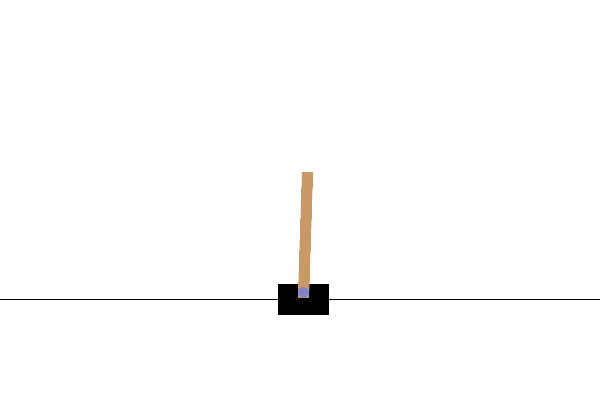

In [4]:
from PIL import Image

# env.render()
img = env.render()
Image.fromarray(img)

In [5]:
env.action_space

Discrete(2)

In [6]:
action = 1
observation, reward, terminated, truncated, info = env.step(action)

print("observation:", observation)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
print("info:", info)

observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
reward: 1.0
terminated: False
truncated: False
info: {}


In [7]:
reward

1.0

In [8]:
terminated

False

In [9]:
truncated

False

In [10]:
info

{}

##### A Basic Policy

In [11]:
from typing import Tuple

import pandas as pd

def basic_policy(observation: Tuple[float, float, float, float]) -> int:
    return 0 if observation[2] < 0 else 1

env = gym.make("CartPole-v1", render_mode="human")
# env = gym.make("CartPole-v1", render_mode="rgb_array")

rewards_episode = []
# for i_episode in range(500):
for i_episode in range(10):
    reward_episode = 0
    observation, info = env.reset()
    for i_step in range(200):
        action = basic_policy(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        reward_episode += reward
        if terminated:
            break
    rewards_episode.append(reward_episode)
env.close()

In [12]:
s_rewards = pd.Series(rewards_episode)
s_rewards.describe()

count    10.000000
mean     46.500000
std      10.731573
min      31.000000
25%      40.500000
50%      43.000000
75%      56.000000
max      62.000000
dtype: float64

<Axes: >

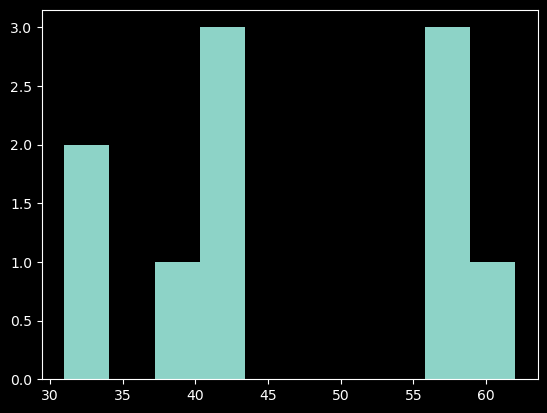

In [13]:
s_rewards.hist(grid=False)